---
title: "Decision Tree Classifier"
format: html
jupyter: python3
dir: ltr
---

**Decision Trees (DTs)** are a supervised learning algorithm that learns simple decision rules, to assign predictions to. Example: `If age > 30` and `income < 50,000` then: `y=1`, else: `y=0`.

DTs can be used in both classification and regression tasks.

`DecisionTreeClassifier` takes as input two arrays:

1. an array of training samples `X`, sparse or dense, of shape `(n_samples, n_features)`
2. an array of training class labels `Y` of integer values, of shape `(n_samples,)`

For instance, in the example below, decision trees learn from data to approximate a sine curve with a set of if-then-else decision rules. The deeper the tree, the more complex the decision rules and the fitter the model.

In [ ]:
from sklearn.datasets import load_iris

![Figure: Iris Flowers Dataset](./assets/iris_flowers.png)

In [27]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

In [31]:
import pandas as pd

pd.concat([iris.data, iris.target], axis=1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [32]:
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

After being fitted, the model can then be used to predict the class of samples:

In [38]:
clf.predict([
    [5.1, 3.5, 1.4, 0.2],
    # [6.7, 3.0, 5.2, 2.3],
])

/home/halgoz/work/udacity-c6/c6/content/modules/M1/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

The *probability* of each class can be predicted, which is: **the fraction of training samples of the class in a leaf**:

In [39]:
clf.predict_proba([
    [5.1, 3.5, 1.4, 0.2]
])

/home/halgoz/work/udacity-c6/c6/content/modules/M1/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

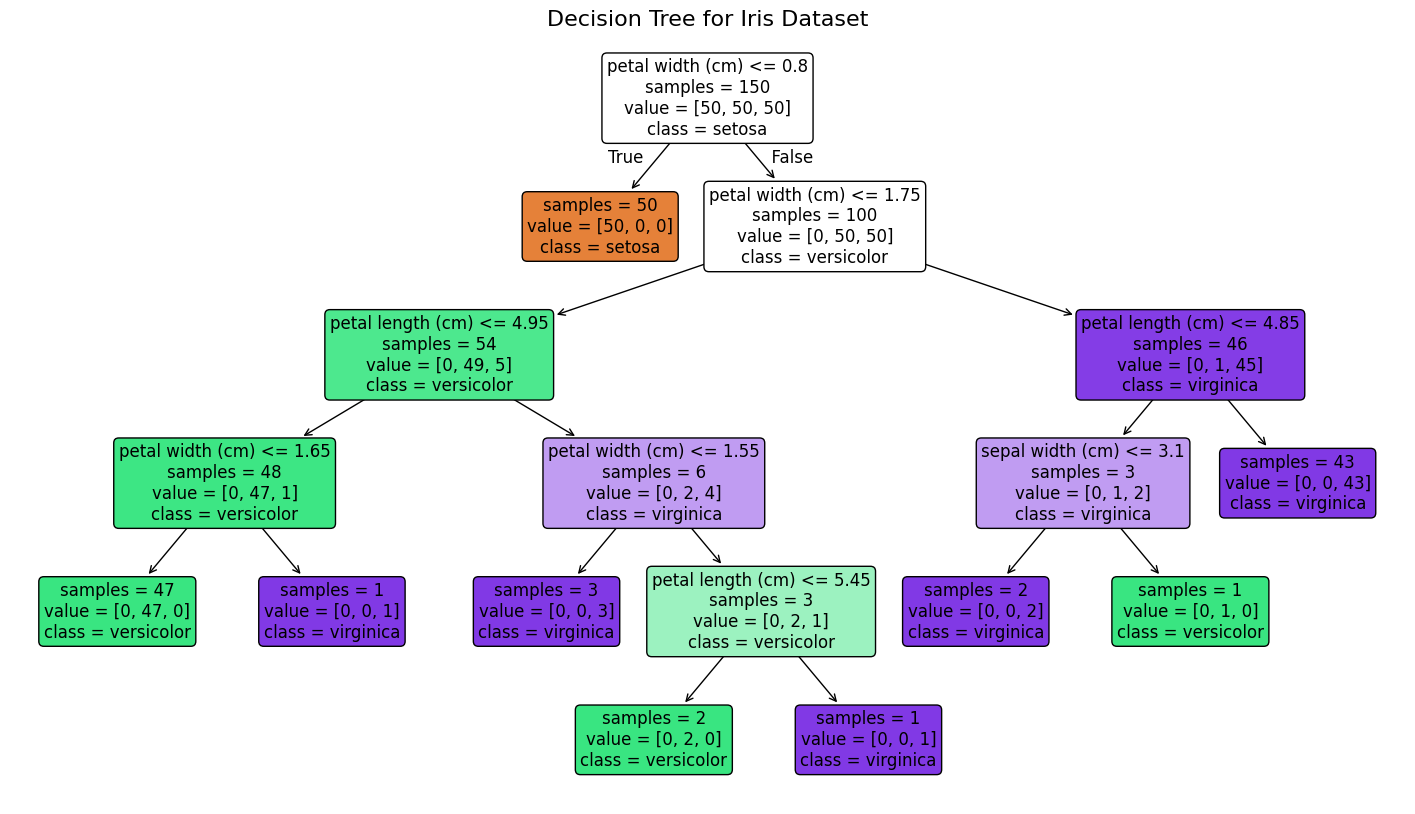

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
tree.plot_tree(
    clf, 
    feature_names=iris.feature_names, 
    class_names=iris.target_names, 
    filled=True, 
    rounded=True, 
    fontsize=12,
    proportion=False,
    impurity=False # Hides impurity to reduce clutter
)
plt.title("Decision Tree for Iris Dataset", fontsize=16)
plt.show()

[Understanding the decision tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html) will help in gaining more insights about how the decision tree makes predictions, which is important for understanding the important features in the data.

TODO: Decision Boundaries.

## Advantages

**"White Box"**: Simple to understand and to interpret. This is their fundamental advantage. You can map the exact sequence of logical conditions the algorithm evaluated to reach a conclusion. If a medical triage model recommends prescribing antibiotics, you can trace the decision branches back to see exactly why (e.g., `"Body Temperature > 38°C"` AND `"Rapid Strep Test = Positive"`). Trees can also be visualized. You do not get this level of interpretability with Deep Neural Networks (a **"Black Box"**).

Secondly, they can do both **Regression and Classification**.

Thirdlay, they can handle **Multi-output problems**.

Fourthly, **inference cost is logarithmic** in the number of data points used to train the tree. That means even if your dataset is massive, the time it takes to make a prediction barely increases.

## Avoid Overfitting

Decision trees **tend to overfit on data with a small samples-to-features ratio**. A decision tree will keep growing branches until it has **a specific rule for every single data point**.

In `scikit-learn`, restricting a decision tree so it doesn't memorize your training data is known as **regularization** or **pruning**.

If you are just starting out, adjusting **`max_depth`** and **`min_samples_leaf`** will give you the most immediate control over overfitting.

### 1. The Manual Approach: Setting Limits Directly

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the tree and set your boundaries right from the start
# We cap the tree at 5 questions deep and force at least 10 data points per final leaf.
my_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10
)

# Train the model on your data (X contains your data, y contains the answers)
# my_tree.fit(X, y)

### 2. The Automated Approach: Grid Search

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Create a blank tree with no rules yet
blank_tree = DecisionTreeClassifier()

# 2. Create your "menu" of options to test (this is your grid)
options_to_test = {
    'max_depth': [3, 5, 7, 10, None],  # Test shallow, medium, deep, and unrestricted
    'min_samples_leaf': [2, 5, 10, 20] # Test different bucket sizes
}

# 3. Set up the automated tester
# cv=5 means "Cross-Validation". It tests every combination 5 separate times 
# on different slices of your data to ensure the results aren't just a lucky fluke.
automated_tester = GridSearchCV(
    estimator=blank_tree,
    param_grid=options_to_test,
    cv=5
)

# 4. Start the test (this might take a moment depending on how big your data and menu are)
# automated_tester.fit(X, y)

# 5. Print out the winning combination!
# print("The best limits to use are:", automated_tester.best_params_)

Here is the full list of the hyperparameters you can set to stop this from happening, broken down by how they control the tree:


### **1. Controlling the Architecture (Pre-pruning)**

These parameters stop the tree from growing too large in the first place.

#### `max_depth`

  * **What it does:** Sets a hard limit on how many levels (or questions) deep the tree can go.
  * **How it helps:** By changing this from its default (`None`) to a specific number (like 3, 5, or 10), you force the algorithm to stop drilling down into hyper-specific patterns. It keeps the model focused on the broad, general rules.


#### `min_samples_split`

  * **What it does:** Dictates the minimum number of data points a branch must have before it is allowed to split again.
  * **How it helps:** If you set this to 20, any "bucket" of data containing 19 or fewer samples will refuse to split further. This stops the tree from creating complex rules just to satisfy a tiny handful of data points.


#### `min_samples_leaf`

  * **What it does:** Dictates the minimum number of data points that *must* end up in a final leaf node after a split.
  * **How it helps:** A split will only be allowed if both the resulting left and right branches contain at least this many samples. This is highly effective at preventing the tree from isolating random outliers into their own custom leaves.


#### `max_leaf_nodes`

  * **What it does:** Caps the total number of endpoints the tree is allowed to have.
  * **How it helps:** If set to 15, the algorithm will find the 15 most important splits (the ones that reduce the most error) and then strictly stop.

### **2. Introducing Randomness**

#### `max_features`

* **What it does:** Limits how many variables (columns) the algorithm is allowed to look at when deciding how to split a node.
* **How it helps:** If you have 20 variables, you can tell the tree to only consider a random subset of 5 variables at every split. This forces the tree to look for alternative patterns and prevents it from becoming overly dependent on just one dominant variable.





### **3. Mathematical Pruning (Post-pruning)**

#### `ccp_alpha` (Cost-Complexity Pruning)

* **What it does:** It allows the tree to grow fully, but then mathematically calculates the "cost" of each branch. It penalizes branches that are overly complex but don't add much predictive value.
* **How it helps:** Increasing this number acts like a pair of hedge clippers. A higher `ccp_alpha` snips off weak branches from the bottom up, leaving you with a simpler, more robust tree.

[See Example: Post pruning decision trees with cost complexity pruning](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py).

Learn more [Tips on Practical Use](https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use).